<a href="https://colab.research.google.com/github/SLCFLAB/Fintech2026-2/blob/main/DL08_CNN/CNN_3_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN 3. Classification: 처음부터 학습 vs Pretrained 모델 활용 (Transfer learning)

| 순서 | 내용 |
|---|---|
| 1 | 데이터: 개미 vs 벌 실제 사진 244장 (PyTorch 공식 튜토리얼 데이터) |
| 2 | 모델 4개 비교: 직접 설계 CNN / ResNet18 scratch / ResNet18 pretrained (freeze, fine-tune) |
| 3 | 결과 분석 + 활용 팁 |

- 전체 실행 시간: T4 GPU 기준 1~2분 예상 (데이터 다운로드 45MB 포함)

출처(기반 코드): https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html, https://github.com/Harry24k/Pytorch-Basic

In [1]:
import os, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torchvision.datasets.utils import download_and_extract_archive
from torchvision.models import resnet18, ResNet18_Weights
import numpy as np
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print("device:", DEVICE)

device: cuda


## 1. 데이터 준비

**데이터**: 인터넷에서 모은 개미(ants)와 벌(bees) 사진. 크기·배경·구도가 제각각인 **실제 사진**.
- train 244장, val 153장 → 딥러닝 기준으로 **아주 적은 양**
- 현실에서도 흔한 상황임 (예: 불량 부품 사진 수백 장, 특정 서류 이미지 수백 장)

**폴더 구조 = label** (`ImageFolder` 규칙). 내 데이터로 해볼 때도 폴더만 이렇게 만들면 그대로 쓸 수 있음.
```
hymenoptera_data/
├── train/
│   ├── ants/  *.jpg
│   └── bees/  *.jpg
└── val/
    ├── ants/
    └── bees/
```

In [2]:
DATA_DIR = "./data/hymenoptera_data"
if not os.path.exists(DATA_DIR):       # 없을 때만 다운로드 (약 45MB)
    download_and_extract_archive("https://download.pytorch.org/tutorial/hymenoptera_data.zip", download_root="./data")

# 크기가 제각각인 사진을 256x256으로 통일해서 uint8 Tensor로 읽어둠 (JPEG 해석은 처음 한 번만)
load_tf = transforms.Compose([
    transforms.Resize(256),            # 짧은 변을 256으로
    transforms.CenterCrop(256),        # 가운데 256x256
    transforms.PILToTensor(),          # uint8 [3, 256, 256]
])

def load_split(split):
    ds = dsets.ImageFolder(os.path.join(DATA_DIR, split), transform=load_tf)   # 폴더 이름 → label
    x = torch.stack([ds[i][0] for i in range(len(ds))])
    y = torch.tensor(ds.targets)
    return x.to(DEVICE), y.to(DEVICE), ds.classes

t0 = time.time()
train_x, train_y, CLASSES = load_split("train")
test_x,  test_y,  _       = load_split("val")          # val 폴더를 test로 사용
print(f"classes: {CLASSES} | train {tuple(train_x.shape)} | test {tuple(test_x.shape)} | {time.time() - t0:.1f}s")

100%|██████████| 47.3M/47.3M [00:00<00:00, 249MB/s]


classes: ['ants', 'bees'] | train (244, 3, 256, 256) | test (153, 3, 256, 256) | 2.8s


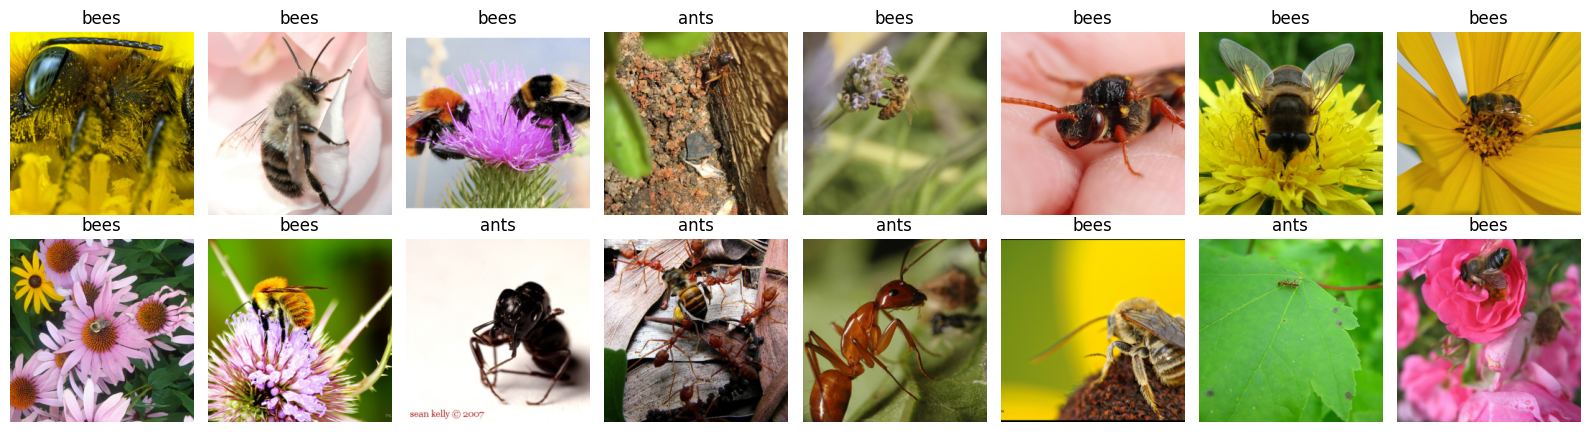

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4.4))
for ax, i in zip(axes.flat, torch.randperm(len(train_x))[:16]):
    ax.imshow(train_x[i].permute(1, 2, 0).cpu()); ax.set_title(CLASSES[train_y[i]]); ax.axis("off")
plt.tight_layout(); plt.show()

**전처리**
- `Normalize(IMAGENET_MEAN, IMAGENET_STD)`: pretrained 모델은 ImageNet 통계로 정규화된 입력으로 학습됨 → **같은 방식으로 넣어줘야 함**
- 입력 크기 224×224: ImageNet pretrained 모델의 표준 입력 크기
- **Data augmentation** (train만): 256×256에서 랜덤 위치 224×224 crop + 좌우 반전 → 적은 데이터에서 overfitting 완화
- test는 가운데 224×224 crop만

In [4]:
IMG_SIZE   = 224
EPOCHS     = 10
BATCH_SIZE = 32

IMAGENET_MEAN, IMAGENET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
MEAN = torch.tensor(IMAGENET_MEAN, device=DEVICE).view(1, 3, 1, 1)
STD  = torch.tensor(IMAGENET_STD,  device=DEVICE).view(1, 3, 1, 1)


def random_flip_crop(x, size):
    # transforms.RandomHorizontalFlip + RandomCrop(size) 를 batch 단위로 GPU에서 수행
    B, C, H, W = x.shape
    flip = torch.rand(B, device=x.device) < 0.5                       # 샘플마다 50% 확률로 좌우 반전
    x = torch.where(flip.view(B, 1, 1, 1), x.flip(3), x)
    dy = torch.randint(0, H - size + 1, (B, 1, 1), device=x.device)   # 샘플마다 다른 crop 위치
    dx = torch.randint(0, W - size + 1, (B, 1, 1), device=x.device)
    rows = (dy + torch.arange(size, device=x.device).view(1, size, 1)).expand(B, size, size)
    cols = (dx + torch.arange(size, device=x.device).view(1, 1, size)).expand(B, size, size)
    b = torch.arange(B, device=x.device).view(B, 1, 1).expand(B, size, size)
    return x[b, :, rows, cols].permute(0, 3, 1, 2)                    # [B, H, W, C] → [B, C, H, W]


def preprocess(x, train):
    # x: uint8 [B, 3, 256, 256] → 모델 입력 [B, 3, 224, 224]
    x = x.float() / 255                                               # = ToTensor (0~255 → 0~1)
    if train:
        x = random_flip_crop(x, IMG_SIZE)                             # = RandomCrop + RandomHorizontalFlip
    else:
        o = (x.shape[-1] - IMG_SIZE) // 2
        x = x[:, :, o:o + IMG_SIZE, o:o + IMG_SIZE]                   # = CenterCrop
    return (x - MEAN) / STD                                           # = Normalize(ImageNet 통계)


class GPULoader:
    # DataLoader 대용: GPU에 올려둔 데이터를 batch로 잘라서 전처리까지 GPU에서 함
    def __init__(self, x, y, batch_size, train):
        self.x, self.y, self.batch_size, self.train = x, y, batch_size, train

    def __len__(self):
        return (len(self.x) + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        n = len(self.x)
        idx = torch.randperm(n, device=self.x.device) if self.train else torch.arange(n, device=self.x.device)   # train만 shuffle
        for i in range(0, n, self.batch_size):
            j = idx[i:i + self.batch_size]
            yield preprocess(self.x[j], self.train), self.y[j]


train_loader = GPULoader(train_x, train_y, batch_size=BATCH_SIZE, train=True)
test_loader  = GPULoader(test_x,  test_y,  batch_size=64,         train=False)

## 2. 모델 4개 비교

| 이름 | 구조 | 초기 weight | 학습 범위 |
|---|---|---|---|
| (A) AlexNet-style | 직접 설계 (AlexNet 경량화) | random | 전체 |
| (B) ResNet18 scratch | ResNet18 | random | 전체 |
| (C) ResNet18 frozen | ResNet18 | **ImageNet pretrained** | 마지막 fc만 (linear probing) |
| (D) ResNet18 fine-tune | ResNet18 | **ImageNet pretrained** | 전체 (작은 lr) |

(B) vs (D)는 **구조가 완전히 같고 초기 weight만 다름** → pretrained의 효과만 분리해서 볼 수 있음.

### (A) AlexNet-style CNN
- **Global Average Pooling + 작은 FC** 로 네트워크 가볍게 만듦.

In [5]:
NUM_CLASSES = len(CLASSES)   # 2 (ants, bees)


class AlexNetStyle(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(                                 # 입력 [B, 3, 224, 224]
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),       # [B, 64, 112, 112]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                            # [B, 64, 56, 56]
            nn.Conv2d(64, 192, kernel_size=3, padding=1),               # [B, 192, 56, 56]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                            # [B, 192, 28, 28]
            nn.Conv2d(192, 256, kernel_size=3, padding=1),              # [B, 256, 28, 28]
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),                                    # [B, 256, 1, 1]  GAP: 채널별 평균 → 입력 크기와 무관
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),                                            # overfitting 방지 (train 모드에서만 동작)
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_resnet18(pretrained, freeze=False):
    weights = ResNet18_Weights.DEFAULT if pretrained else None          # 구버전의 pretrained=True 대신 weights= 사용
    model = resnet18(weights=weights)
    if freeze:
        for p in model.parameters():
            p.requires_grad = False                                     # backbone 고정 → gradient 계산 안 함
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)             # ImageNet 1000 class → 2 class로 교체 (새 layer는 학습됨)
    return model


count = lambda m: (sum(p.numel() for p in m.parameters()), sum(p.numel() for p in m.parameters() if p.requires_grad))
for name, m in [("AlexNet-style", AlexNetStyle()), ("ResNet18", build_resnet18(False)), ("ResNet18 frozen", build_resnet18(True, freeze=True))]:
    total, trainable = count(m)
    print(f"{name:<16} total {total:>11,}   trainable {trainable:>11,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


AlexNet-style    total   1,145,794   trainable   1,145,794
ResNet18         total  11,177,538   trainable  11,177,538
ResNet18 frozen  total  11,177,538   trainable       1,026


### 학습 함수
epoch마다 **train accuracy와 test accuracy를 같이 기록** → 둘의 차이로 overfitting 여부를 판단함.

In [6]:
@torch.no_grad()
def accuracy(model, loader):
    model.eval()                                   # Dropout off, BatchNorm은 학습된 통계 사용
    correct = total = 0
    for x, y in loader:
        pred = model(x.to(DEVICE)).argmax(1)
        correct += (pred == y).sum().item(); total += len(y)
    return correct / total * 100


def fit(model, lr, epochs=EPOCHS):
    model.to(DEVICE)
    # requires_grad=True인 parameter만 optimizer에 넘김 (freeze한 부분 제외)
    optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    criterion = nn.CrossEntropyLoss()
    hist = {"train": [], "test": []}
    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        correct = total = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            correct += (out.argmax(1) == y).sum().item(); total += len(y)
        hist["train"].append(correct / total * 100)            # augmentation 걸린 train 데이터 기준 정확도
        hist["test"].append(accuracy(model, test_loader))
        print(f"  epoch {epoch+1:2d}/{epochs}  train {hist['train'][-1]:5.1f}%  test {hist['test'][-1]:5.1f}%")
    print(f"  ({time.time() - t0:.0f}s)")
    return hist

In [7]:
results = {}
print("(A) AlexNet-style, scratch");   results["(A) AlexNet-style"]    = fit(AlexNetStyle(), lr=1e-3)
print("(B) ResNet18, scratch");        results["(B) ResNet18 scratch"] = fit(build_resnet18(False), lr=1e-3)
print("(C) ResNet18, pretrained + freeze"); results["(C) ResNet18 frozen"] = fit(build_resnet18(True, freeze=True), lr=1e-3)
# fine-tuning은 lr을 작게: 이미 좋은 weight를 크게 흔들면 pretrained 지식이 망가짐
print("(D) ResNet18, pretrained + fine-tune"); model_ft = build_resnet18(True)
results["(D) ResNet18 fine-tune"] = fit(model_ft, lr=1e-4)

(A) AlexNet-style, scratch
  epoch  1/10  train  49.6%  test  54.2%
  epoch  2/10  train  50.4%  test  54.9%
  epoch  3/10  train  54.1%  test  62.7%
  epoch  4/10  train  66.8%  test  64.1%
  epoch  5/10  train  71.7%  test  64.7%
  epoch  6/10  train  70.1%  test  64.1%
  epoch  7/10  train  66.4%  test  68.6%
  epoch  8/10  train  70.9%  test  66.0%
  epoch  9/10  train  73.0%  test  69.9%
  epoch 10/10  train  73.0%  test  64.1%
  (6s)
(B) ResNet18, scratch
  epoch  1/10  train  51.6%  test  45.1%
  epoch  2/10  train  66.0%  test  58.8%
  epoch  3/10  train  71.3%  test  65.4%
  epoch  4/10  train  75.4%  test  56.9%
  epoch  5/10  train  76.2%  test  60.1%
  epoch  6/10  train  74.6%  test  63.4%
  epoch  7/10  train  75.8%  test  63.4%
  epoch  8/10  train  76.2%  test  68.6%
  epoch  9/10  train  79.9%  test  67.3%
  epoch 10/10  train  72.5%  test  72.5%
  (11s)
(C) ResNet18, pretrained + freeze
  epoch  1/10  train  77.9%  test  90.2%
  epoch  2/10  train  89.8%  test  92.2%


## 3. 결과 분석

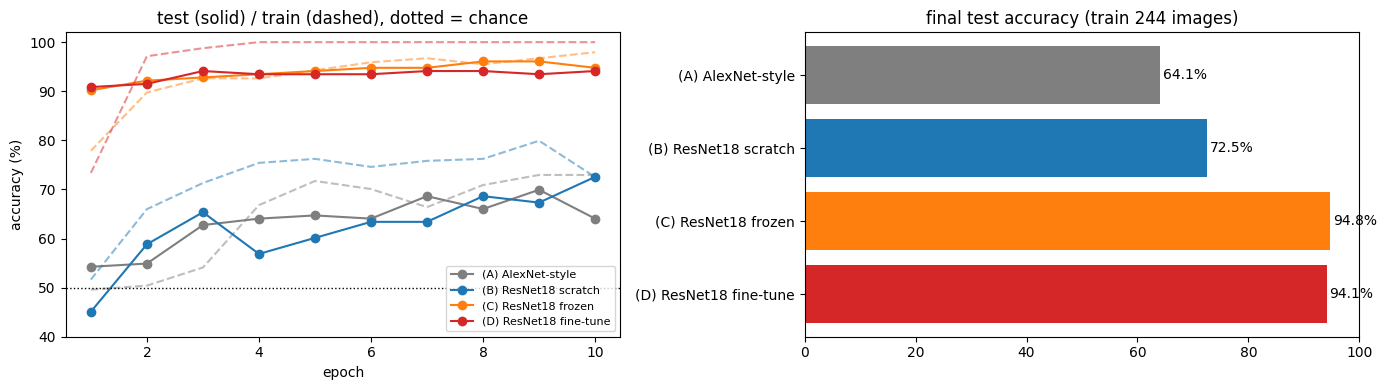

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for (name, h), c in zip(results.items(), ["tab:gray", "tab:blue", "tab:orange", "tab:red"]):
    ep = range(1, len(h["test"]) + 1)
    axes[0].plot(ep, h["test"], "o-", c=c, label=name)
    axes[0].plot(ep, h["train"], "--", c=c, alpha=0.5)
axes[0].axhline(50, ls=":", c="k", lw=1)                               # 2-class 찍기 수준
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy (%)"); axes[0].set_title("test (solid) / train (dashed), dotted = chance")
axes[0].set_ylim(40, 102); axes[0].legend(fontsize=8, loc="lower right")
names = list(results)
axes[1].barh(names, [results[n]["test"][-1] for n in names], color=["tab:gray", "tab:blue", "tab:orange", "tab:red"])
for i, n in enumerate(names):
    axes[1].text(results[n]["test"][-1] + 0.5, i, f"{results[n]['test'][-1]:.1f}%", va="center")
axes[1].set_xlim(0, 100); axes[1].invert_yaxis(); axes[1].set_title(f"final test accuracy (train {len(train_x)} images)")
plt.tight_layout(); plt.show()

**해석**
- (B) vs (D): **같은 구조**인데 초기 weight만 다름. 처음부터 학습한 (B)는 10 epoch 후에도 60~70%대(찍기 = 50%)에 머물지만, pretrained (D)는 **1 epoch 만에 90% 안팎**
  → ImageNet(120만 장)에서 배운 edge, 질감, 모양 feature를 그대로 가져다 씀
- (C) frozen: 1100만 개 중 **fc layer 1,026개만 학습** 했는데 fine-tune (D)와 비슷하거나 더 좋음
  → 데이터가 적을수록 **적게 학습하는 쪽이 안정적**. 가장 빠르기도 함
- (D) fine-tune: 후반 epoch에 test가 조금 떨어질 수 있음 → train만 계속 오르는 **overfitting** 신호
- (A), (B): 244장으로는 처음부터 학습하는 게 거의 불가능함. 큰 모델(B)은 epoch마다 크게 출렁이기도 함
- 초반 epoch에 train accuracy < test accuracy 인 이유: train은 augmentation + Dropout이 걸린 *더 어려운* 데이터로 측정하기 때문

### Fine-tuned 모델 오답 살펴보기

test 153장 중 오답 9장


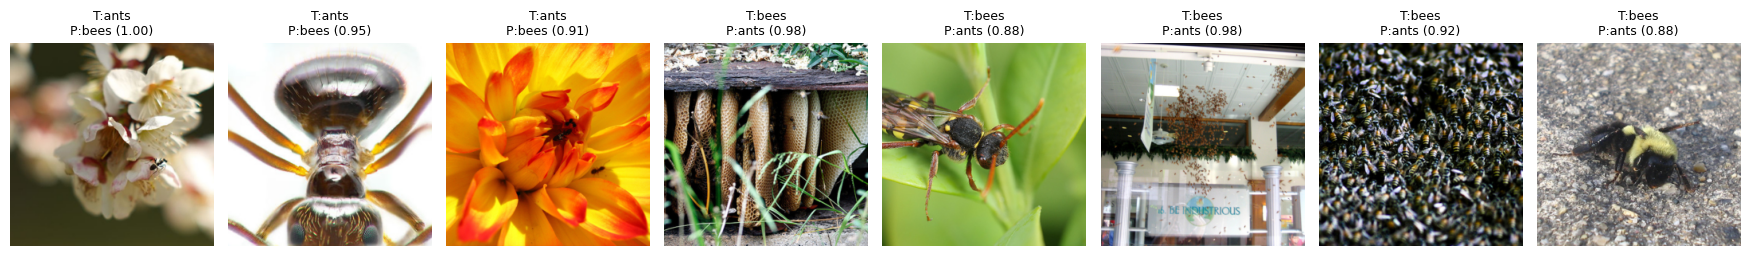

In [9]:
model_ft.eval()
with torch.no_grad():
    prob = torch.cat([torch.softmax(model_ft(x), 1) for x, _ in test_loader]).cpu()
pred, y = prob.argmax(1), test_y.cpu()
wrong = (pred != y).nonzero().flatten()[:8]
print(f"test {len(y)}장 중 오답 {(pred != y).sum().item()}장")

fig, axes = plt.subplots(1, len(wrong), figsize=(2.2 * len(wrong), 2.8), squeeze=False)
for ax, i in zip(axes[0], wrong):
    ax.imshow(test_x[i].permute(1, 2, 0).cpu())                          # 전처리 전 원본(uint8) 표시
    ax.set_title(f"T:{CLASSES[y[i]]}\nP:{CLASSES[pred[i]]} ({prob[i].max():.2f})", fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

- 틀린 사진 대부분은 (1) **꽃 위에 작게 찍힌 개미** → bees로, (2) **벌 한 마리가 뚜렷하지 않은 벌집·벌떼 사진** → ants로 예측한 경우임 (실행마다 조금 다를 수 있음)
- 위 샘플 사진을 보면 벌 사진엔 대부분 꽃이 있음 → 모델이 벌레 자체보다 **배경(꽃)을 단서로 쓰는 shortcut 학습** 을 했을 가능성
- 말벌처럼 보이는 사진이 bees로 되어 있는 등 **label 자체가 애매한** 경우도 있음
- 데이터가 적을수록 이런 문제가 생기기 쉽고, **오답을 직접 봐야** 발견할 수 있음

---
## Discussion
1. 이 실험에서 (C) frozen이 (D) fine-tune만큼 좋았던 이유는?
   - 244장으로 1100만 개 parameter 전체를 조정하면 overfitting 위험이 큼. frozen은 fc 1,026개만 학습해서 적은 데이터에도 안정적임. 데이터가 많아지면 보통 fine-tune이 더 좋아짐.
2. ImageNet과 매우 다른 이미지(X-ray, 위성사진, 차트 이미지 등)에도 pretrained 모델이 도움이 될까?
   - 대부분 도움 됨. edge, 질감 같은 기초 feature는 도메인과 무관하게 쓸모 있음. 단, 차이가 클수록 freeze보다 전체 fine-tuning이 필요하고, 해당 도메인용 pretrained 모델이 있으면 그게 더 좋음.

## Summary
이미지 모델이 필요하다면:
1. **처음부터 설계/학습하지 말고 pretrained backbone부터** (torchvision, `timm`, Hugging Face Hub에 수천 개 있음)
2. 순서: **freeze + fc 학습 (빠른 baseline)** → 부족하면 **전체 fine-tuning (작은 lr, 1e-4 ~ 1e-5)**
   - 주의: `requires_grad=False` 로 freeze해도 **BatchNorm의 running 통계는 `model.train()` 에서 계속 바뀜** → 완전히 고정하려면 backbone을 `eval()` 모드로 둬야 함
3. **전처리는 pretrained 모델과 똑같이**: `ResNet18_Weights.DEFAULT.transforms()` 로 공식 전처리 확인 가능
4. train/test 곡선을 같이 보며 overfitting 확인, 오답을 직접 보면서 이상한 패턴 확인
5. 요즘은 CLIP 같은 모델로 **학습 없이(zero-shot)** 분류하거나, feature(embedding)만 뽑아서 검색/군집화에 쓰는 방식도 많이 씀